<a href="https://colab.research.google.com/github/GripenNG/signals/blob/main/2_aliasing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aliasing in Sampled Systems

Aliasing is one of those concepts that shows up everywhere - from audio and imaging to radar and communications - but it’s often misunderstood or oversimplified.

In this notebook you can explore some of the concepts I glossed over in the video and play around with the concept of aliasing for yourself.

> Provided as supplemental material for [Marshall Bruner](https://tinyurl.com/marshall-bruner-yt)'s [animated video on aliasing in sampled systems](https://youtu.be/eBHbCZo9QrM).

- [Website (MarshallBruner.com)](https://marshallbruner.com)
- [GitHub](https://tinyurl.com/github-nb)
- [YouTube](https://tinyurl.com/marshall-bruner-yt-nb)

![thumbnail](https://drive.google.com/uc?id=1AP0ew2NglvyVfjgroMKLBSrCj2rc6wOy)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, pi
from scipy import signal
from matplotlib import cm
from numpy.fft import fft, fftshift

%matplotlib inline
plt.style.use("ggplot")
# plt.rcParams.update(
#     {
#         "text.usetex": True,
#         "font.family": "typeface",
#     }
# )  # Makes plotting slower but prettier (requires LaTeX installed)

## Sample Delta Train (Dirac Comb) in the Frequency Domain
Why a delta series in the time domain get Fourier transformed into a delta series in the frequency domain.

### Mathematical explanation

We start with the impulse train in time:

$$
\begin{equation}
p(t) = \sum_{n=-\infty}^{\infty} \delta(t - nT)
\end{equation}
$$

We want to compute its Fourier Transform:

$$
\begin{equation}
P(f) = \int_{-\infty}^{\infty} p(t) e^{-j2\pi ft} \, dt
\end{equation}
$$

Substituting $p(t)$:

$$
\begin{equation}
P(f) = \int_{-\infty}^{\infty} \left( \sum_{n=-\infty}^{\infty} \delta(t - nT) \right) e^{-j2\pi ft} \, dt
\end{equation}
$$

You can then swap the sum and integral

$$
\begin{equation}
P(f) = \sum_{n=-\infty}^{\infty} \int_{-\infty}^{\infty} \delta(t - nT) e^{-j2\pi ft} \, dt
\end{equation}
$$

The *sifting property* states that an infinite integral of some function, $g(t)$ multiplied by a delta function at $t_0$, $\delta(t - t_0)$, will simply pluck out the component at $t_0$.
It can therefore be simplified to only include the $t_0$ component of $g(t)$ or, in other words, $g(t_0)$.
Applying this here gives:

$$
\begin{equation}
\int_{-\infty}^{\infty} \delta(t - nT) e^{-j2\pi ft} \, dt = e^{-j2\pi f nT}
\end{equation}
$$

After simplifying this integral, we can bring it back into the summation to get:

$$
\begin{equation}
P(f) = \sum_{n=-\infty}^{\infty} e^{-j2\pi f nT}
\end{equation}
$$

The summation

$$
\begin{equation}
\sum_{n=-\infty}^{\infty} e^{-j2\pi f nT}
\end{equation}
$$

is recognized as a *Dirac comb* in frequency, producing impulses at multiples of:

$$
\begin{equation}
f_s = \frac{1}{T}
\end{equation}
$$

So:

$$
\begin{equation}
P(f) = f_s \sum_{k=-\infty}^{\infty} \delta(f - k f_s)
\end{equation}
$$

Final result:

$$
\begin{equation}
\boxed{ \mathcal{F}\left\{ \sum_{n=-\infty}^{\infty} \delta(t - nT) \right\} = F_s \sum_{k=-\infty}^{\infty} \delta(f - kF_s) }
\end{equation}
$$

## Why the negative frequency peak?

Let's start with the famous Euler's formula:

\begin{equation}
    e^{j\omega t} = \cos{(\omega t)} + j \sin{(\omega t)}
\end{equation}

where $\omega = 2 \pi f$.

> Quick note: $j$ is the same thing as the imaginary $i$: $j = i = \sqrt{-1}$. Normally mathematicians use $i$ and us *cool* engineers use $j$.

Say we have the input signal, $x(t) = \sin{(\omega t)}$:

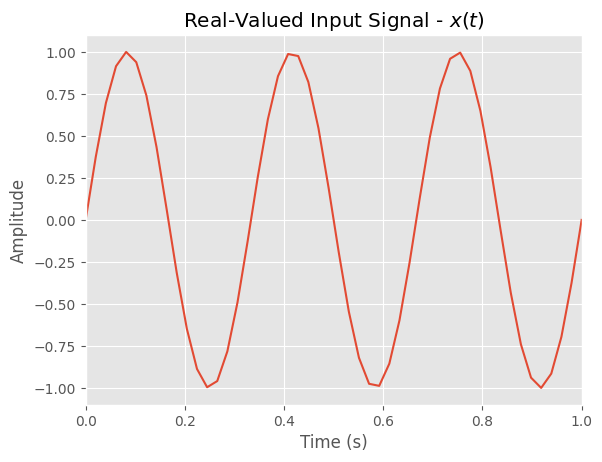

In [ ]:
f = 3
omega = 2 * pi * f
t = np.linspace(0, 1, 50)
x = np.sin(omega * t)
plt.plot(t, x)
plt.title("Real-Valued Input Signal - $x(t)$")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 1)
plt.show()

We can actually rearrange the input, $x(t)$, to get it in terms of complex exponentials, $e^{j \omega t}$, to get:

\begin{equation}
    \sin{(\omega t)} = \frac{1}{2j} (e^{j \omega t} - e^{-j \omega t})
\end{equation}

> Try rearranging these equations yourself to make sure this holds!

This shows that the sine function, $x(t) = \sin{(\omega t)}$, that looks like just one single sinusoid, actually is made up of 2 sinusoids:
- 1 at $+\omega$
- 1 at $-\omega$

This is why when you compute the Fourier transform (which is inherently a complex function) on a real-valued input the output has a peak at $\pm f$.

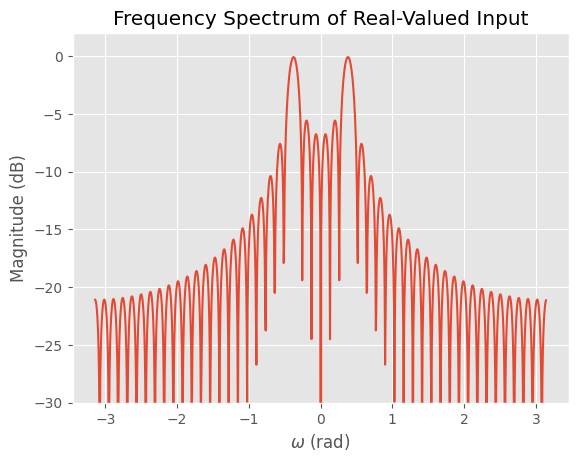

In [ ]:
fftlen = 1024
X = 10 * np.log10(np.abs(fft(x, fftlen)) / (x.size / 2))
omegas = np.linspace(-pi, pi, fftlen)
plt.plot(omegas, fftshift(X))
plt.ylim(-30, 2)
plt.xlabel(r"$\omega$ (rad)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Spectrum of Real-Valued Input")
plt.show()

See? 2 peaks, one at $-f$, and one at $+f$.

But if we were to have a complex valued input signal, $x(t) = e^{j \omega t}$, we would just get a single peak on the output of the Fourier Transform since it's made up of a single complex sinusoid.

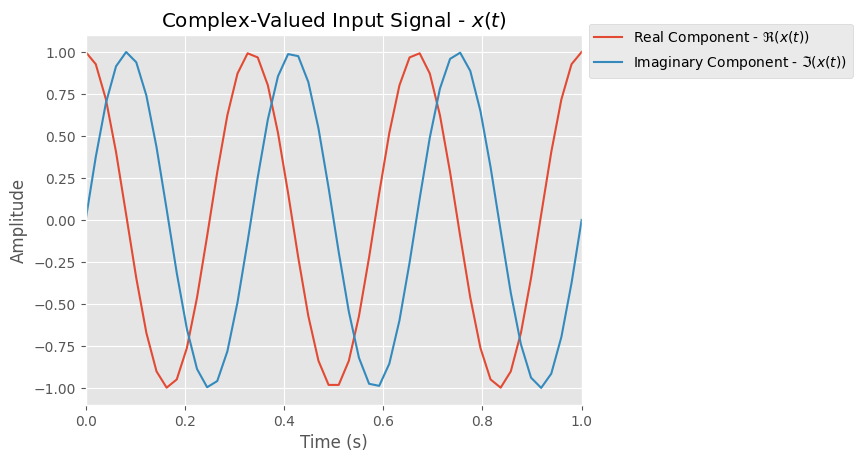

In [ ]:
t = np.linspace(0, 1, 50)
x_complex = np.exp(1j * omega * t)
plt.plot(t, np.real(x_complex), label=r"Real Component - $\Re{(x(t))}$")
plt.plot(t, np.imag(x_complex), label=r"Imaginary Component - $\Im{(x(t))}$")
plt.title("Complex-Valued Input Signal - $x(t)$")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 1)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1.05))
plt.show()

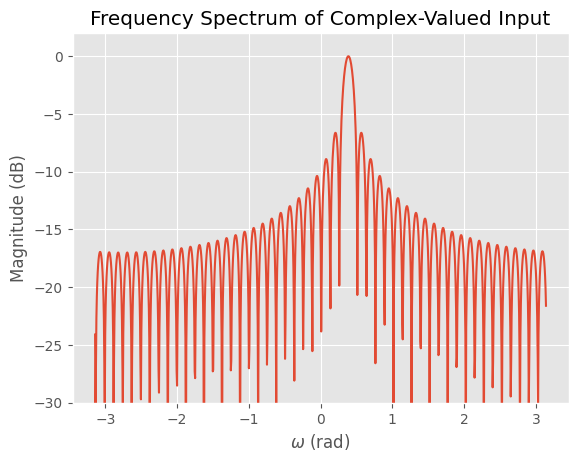

In [ ]:
X_complex = 10 * np.log10(np.abs(fft(x_complex, fftlen)) / (x_complex.size))
plt.plot(omegas, fftshift(X_complex))
plt.ylim(-30, 2)
plt.xlabel(r"$\omega$ (rad)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Spectrum of Complex-Valued Input")
plt.show()

You can even have an negative, complex-valued input signal which would give you a single peak at $-f$, like below:

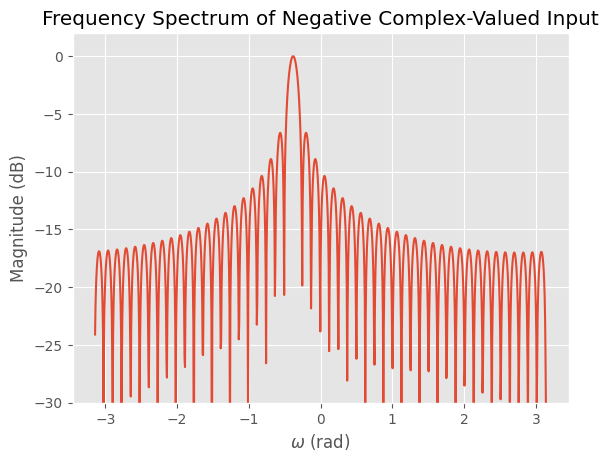

In [ ]:
x_complex_neg = np.exp(-1j * omega * t)  # note the -1j here
X_complex_neg = 10 * np.log10(np.abs(fft(x_complex_neg, fftlen)) / (x_complex_neg.size))
plt.plot(omegas, fftshift(X_complex_neg))
plt.ylim(-30, 2)
plt.xlabel(r"$\omega$ (rad)")
plt.ylabel("Magnitude (dB)")
plt.title("Frequency Spectrum of Negative Complex-Valued Input")
plt.show()

## Play with aliasing for yourself!
This cell allows you to input a specific frequency (or multiple) and see how moving it around affects the frequency spectrum.

Also try keeping the same frequencies and playing around with the sampling frequency, `fs`.

You'll notice that if the input signal has a frequency higher than half the sampling frequency, `fs`, or in other words: $f_{\text{max}} \ge f_s/2$, the output spectrum will start looping back and forth like we saw in the video.
You can even have multiple frequency components without seeing anything on the frequency spectrum at all if you line them up correctly.

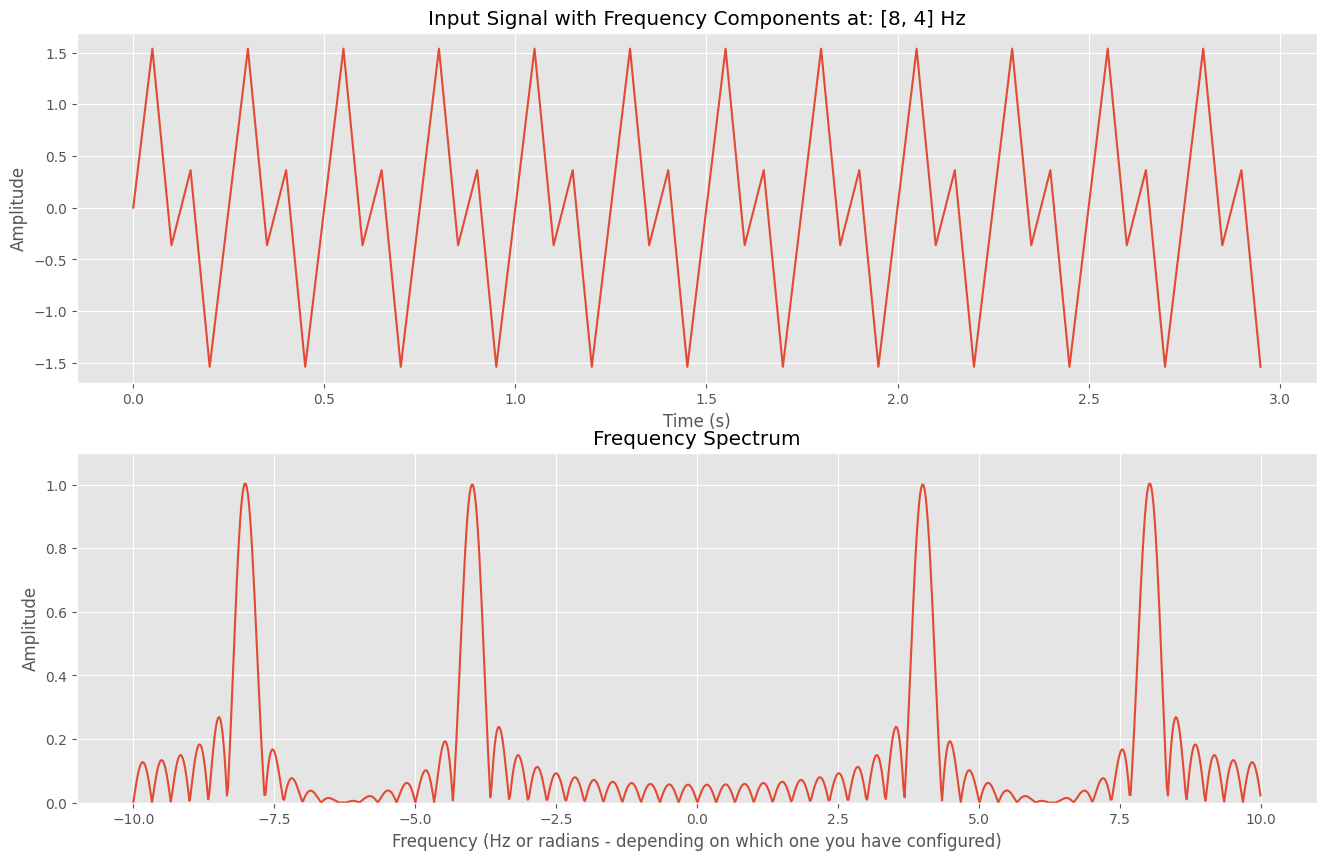

In [ ]:
# CHANGE ME
fs = 20  # Hz

fft_len = 1024  # size of fft (bigger -> finer resolution)
stop_time = 3  # s

# freq = np.linspace(-pi, pi, fft_len)  # frequency in radians (-pi -> pi)
freq = np.linspace(-fs / 2, fs / 2, fft_len)  # frequency in Hz (-fs/2 -> fs/2)


def get_signal_and_spectrum(freqs):
    t = np.arange(0, stop_time, 1 / fs)
    x_n = np.sum([np.sin(2 * pi * f * t) for f in freqs], axis=0)  # input signal

    X_k = fftshift(
        np.abs(fft(x_n, fft_len)) / (t.size / 2)
    )  # frequency spectrum of input signal

    # can't plot a complex signal easily on a 2D grid, so just take the real values
    return t, x_n, np.real(X_k)


# CHANGE ME
# Place any number of frequency components in this array (or modify existing) and watch the output change
frequencies = [
    8,  # Hz
    4,  # Hz
]
t, x_n, X_k = get_signal_and_spectrum(frequencies)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 10))
axes[0].plot(t, x_n)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f"Input Signal with Frequency Components at: {frequencies} Hz")

axes[1].plot(freq, np.real(X_k))
axes[1].set_xlabel(
    "Frequency (Hz or radians - depending on which one you have configured)"
)
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Frequency Spectrum")
axes[1].set_ylim(0, 1.1)
plt.show()